In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pycaret.classification import setup, compare_models,evaluate_model, plot_model, create_model, tune_model, finalize_model, predict_model, save_model
import optuna


# Innits


In [56]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])


data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [57]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


In [58]:
cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


clean_sheets
0    383
1    118
Name: count, dtype: int64


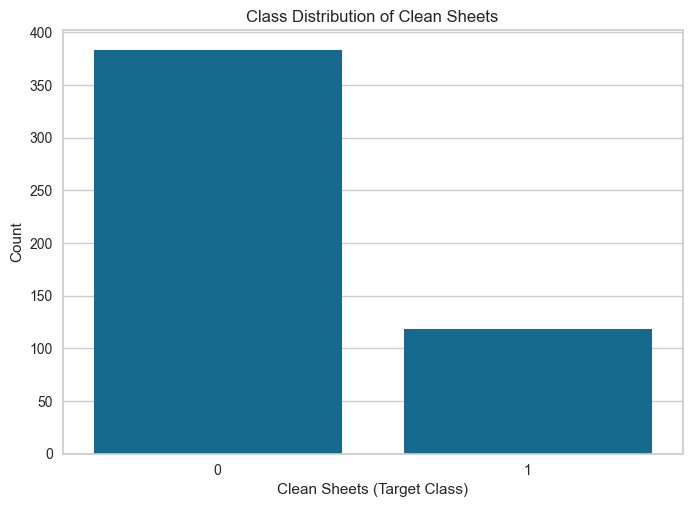

In [59]:
g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[cs_features]
g_cs_data_tar = g_cs_data_tar[cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [60]:
g_cs_base_model = setup(data=g_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        # remove_multicollinearity=True,
                        normalize=True,
                        feature_selection=True,
                        # polynomial_features=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 253, number of negative: 253
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000576 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4677
[LightGBM] [Info] Number of data points in the train set: 506, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(501, 73)"
4,Transformed data shape,"(657, 15)"
5,Transformed train set shape,"(506, 15)"
6,Transformed test set shape,"(151, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [61]:
best_base_g_cs = g_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.5429,0.5607,0.5653,0.2697,0.3604,0.0728,0.0859,0.2400
lightgbm,Light Gradient Boosting Machine,0.6943,0.5368,0.2083,0.2938,0.2379,0.0552,0.0589,0.5540
svm,SVM - Linear Kernel,0.5543,0.5345,0.4708,0.2391,0.3083,0.0252,0.0402,0.2310
xgboost,Extreme Gradient Boosting,0.6571,0.5330,0.2458,0.2684,0.2477,0.0301,0.0336,0.4650
et,Extra Trees Classifier,0.6857,0.5193,0.1125,0.2033,0.1205,-0.0380,-0.0369,0.4530
qda,Quadratic Discriminant Analysis,0.6086,0.5092,0.3194,0.2512,0.2742,0.0172,0.0189,0.2460
dt,Decision Tree Classifier,0.6029,0.5034,0.3167,0.2437,0.2740,0.0098,0.0085,0.2370
dummy,Dummy Classifier,0.7657,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4210
lda,Linear Discriminant Analysis,0.5286,0.4983,0.4514,0.2323,0.3048,-0.0011,0.0024,0.3680
ada,Ada Boost Classifier,0.6114,0.4951,0.2944,0.2395,0.2634,0.0056,0.0040,0.4760


In [62]:
evaluate_model(best_base_g_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [63]:
tune_model_gk_cs = tune_model(best_base_g_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7429,0.7755,0.6250,0.4545,0.5263,0.3558,0.3643
1,0.6571,0.5833,0.2500,0.2500,0.2500,0.0278,0.0278
2,0.6000,0.4745,0.3750,0.2500,0.3000,0.0354,0.0369
3,0.5714,0.5162,0.5000,0.2667,0.3478,0.0708,0.0786
4,0.6000,0.6296,0.5000,0.2857,0.3636,0.1026,0.1111
5,0.6571,0.6181,0.6250,0.3571,0.4545,0.2308,0.2500
6,0.6857,0.5903,0.3750,0.3333,0.3529,0.1463,0.1468
7,0.5714,0.6273,0.6250,0.2941,0.4000,0.1294,0.1517
8,0.6000,0.4530,0.0000,0.0000,0.0000,-0.2250,-0.2402


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [64]:
evaluate_model(tune_model_gk_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [65]:
final_best_base_g_cs = finalize_model(tune_model_gk_cs)
save_model(final_best_base_g_cs, './models/gk_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          random_state

## DEF


clean_sheets
0    1562
1     426
Name: count, dtype: int64


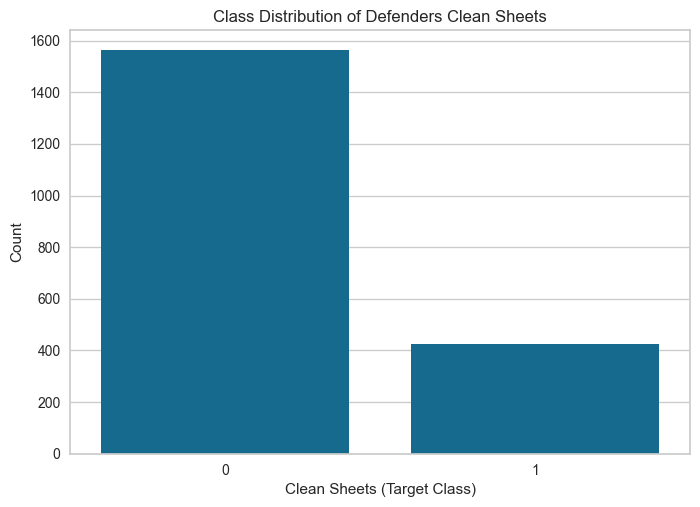

In [66]:
def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[cs_features]
def_cs_data_tar = def_cs_data_tar[cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Defenders Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [67]:
def_cs_base_model = setup(data=def_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1046, number of negative: 1046
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003117 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13892
[LightGBM] [Info] Number of data points in the train set: 2092, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1988, 73)"
4,Transformed data shape,"(2689, 15)"
5,Transformed train set shape,"(2092, 15)"
6,Transformed test set shape,"(597, 15)"
7,Numeric features,71
8,Rows with missing values,0.1%
9,Preprocess,True


In [68]:
best_base_def_cs = def_cs_base_model.compare_models(sort='AUC')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,21:12:01
Status,. . . . . . . . . . . . . . . . . .,Loading Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7771,0.7252,0.3159,0.4745,0.3738,0.2469,0.2565,1.3310
xgboost,Extreme Gradient Boosting,0.7750,0.7192,0.3464,0.4586,0.3906,0.2585,0.2634,0.9420
et,Extra Trees Classifier,0.7714,0.7134,0.3326,0.4645,0.3798,0.2462,0.2551,1.0780
rf,Random Forest Classifier,0.7707,0.7116,0.2993,0.4496,0.3494,0.2205,0.2313,1.7610
gbc,Gradient Boosting Classifier,0.7340,0.6697,0.3360,0.3664,0.3454,0.1816,0.1836,2.3520
ada,Ada Boost Classifier,0.6901,0.6361,0.4160,0.3251,0.3641,0.1637,0.1663,1.1590
knn,K Neighbors Classifier,0.5593,0.6149,0.6313,0.2721,0.3799,0.1152,0.1403,0.6510
lda,Linear Discriminant Analysis,0.5859,0.6078,0.5578,0.2707,0.3629,0.1074,0.1252,1.1920
ridge,Ridge Classifier,0.5852,0.6044,0.5511,0.2688,0.3600,0.1037,0.1204,2.1390
lr,Logistic Regression,0.5830,0.6038,0.5445,0.2662,0.3562,0.0986,0.1142,0.9160


In [69]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [70]:
tune_model_def_cs = tune_model(best_base_def_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8071,0.6852,0.2333,0.6364,0.3415,0.2559,0.3004
1,0.7410,0.6755,0.3103,0.3600,0.3333,0.1737,0.1744
2,0.8201,0.8097,0.6552,0.5588,0.6032,0.4878,0.4904
3,0.7626,0.7349,0.3000,0.4286,0.3529,0.2131,0.2182
4,0.7338,0.6685,0.3333,0.3704,0.3509,0.1840,0.1844
5,0.8201,0.7450,0.4667,0.6087,0.5283,0.4196,0.4252
6,0.7770,0.7343,0.3333,0.4762,0.3922,0.2608,0.2670
7,0.7554,0.7502,0.2333,0.3889,0.2917,0.1549,0.1623
8,0.7554,0.6884,0.3000,0.4091,0.3462,0.2001,0.2037


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [71]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [72]:
final_best_base_def_cs = finalize_model(best_base_def_cs)
save_model(final_best_base_def_cs, './models/def_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                            

## MID


clean_sheets
0    1695
1     500
Name: count, dtype: int64


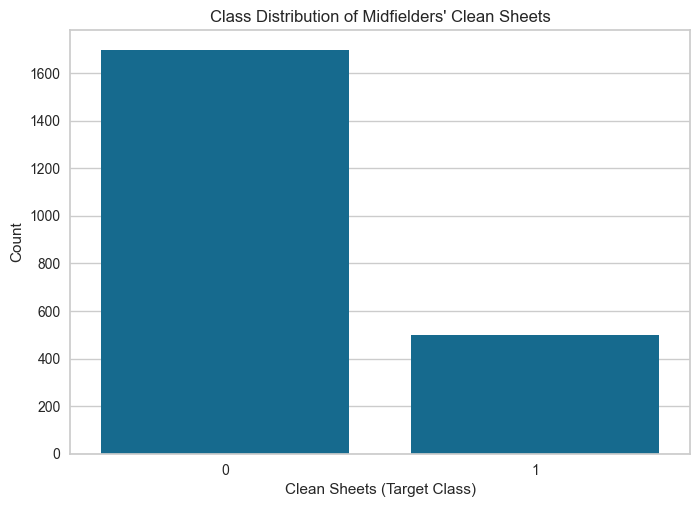

In [73]:
mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[cs_features]
mid_cs_data_tar = mid_cs_data_tar[cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Midfielders\' Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [74]:
mid_cs_base_model = setup(data=mid_cs_data, target='clean_sheets',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1135, number of negative: 1135
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.239866 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14230
[LightGBM] [Info] Number of data points in the train set: 2270, number of used features: 65
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(2195, 73)"
4,Transformed data shape,"(2929, 15)"
5,Transformed train set shape,"(2270, 15)"
6,Transformed test set shape,"(659, 15)"
7,Numeric features,71
8,Preprocess,True
9,Imputation type,simple


In [75]:
best_base_mid_cs = mid_cs_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7787,0.7331,0.3057,0.5357,0.3843,0.2620,0.2797,1.2850
lightgbm,Light Gradient Boosting Machine,0.7819,0.7284,0.3114,0.5518,0.3952,0.2740,0.2926,2.6630
xgboost,Extreme Gradient Boosting,0.7845,0.7200,0.3543,0.5440,0.4256,0.3012,0.3132,1.9990
rf,Random Forest Classifier,0.7702,0.7179,0.3086,0.5037,0.3806,0.2490,0.2617,1.6900
gbc,Gradient Boosting Classifier,0.7644,0.6883,0.2857,0.4959,0.3575,0.2246,0.2408,2.1020
ada,Ada Boost Classifier,0.6869,0.6393,0.3829,0.3416,0.3582,0.1538,0.1552,1.5420
dt,Decision Tree Classifier,0.6999,0.6063,0.4343,0.3667,0.3960,0.1990,0.2010,3.7450
knn,K Neighbors Classifier,0.5384,0.6032,0.6371,0.2773,0.3860,0.1007,0.1233,1.9710
ridge,Ridge Classifier,0.5664,0.6026,0.6086,0.2867,0.3890,0.1159,0.1370,1.8490
lda,Linear Discriminant Analysis,0.5664,0.6026,0.6086,0.2867,0.3890,0.1159,0.1370,1.0310


In [76]:
evaluate_model(best_base_mid_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [77]:
tune_model_mid_cs = tune_model(best_base_mid_cs,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6169,0.6583,0.4286,0.2778,0.3371,0.0846,0.0886
1,0.6299,0.5930,0.4857,0.3036,0.3736,0.1304,0.1376
2,0.6688,0.6980,0.5143,0.3462,0.4138,0.1951,0.2025
3,0.6104,0.6377,0.4571,0.2807,0.3478,0.0922,0.0977
4,0.6818,0.6828,0.4857,0.3542,0.4096,0.1991,0.2038
5,0.6688,0.6430,0.4286,0.3261,0.3704,0.1513,0.1539
6,0.6928,0.7281,0.7143,0.4032,0.5155,0.3152,0.3429
7,0.6209,0.6446,0.5143,0.3051,0.3830,0.1344,0.1440
8,0.6144,0.6368,0.3714,0.2600,0.3059,0.0503,0.0518


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [78]:
evaluate_model(tune_model_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [79]:
final_best_base_mid_cs = finalize_model(best_base_mid_cs)
save_model(final_best_base_mid_cs, './models/mid_cs_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                  ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0,
                               

# Yellow Cards


In [80]:
y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


## GK


yellow_cards
0    458
1     43
Name: count, dtype: int64


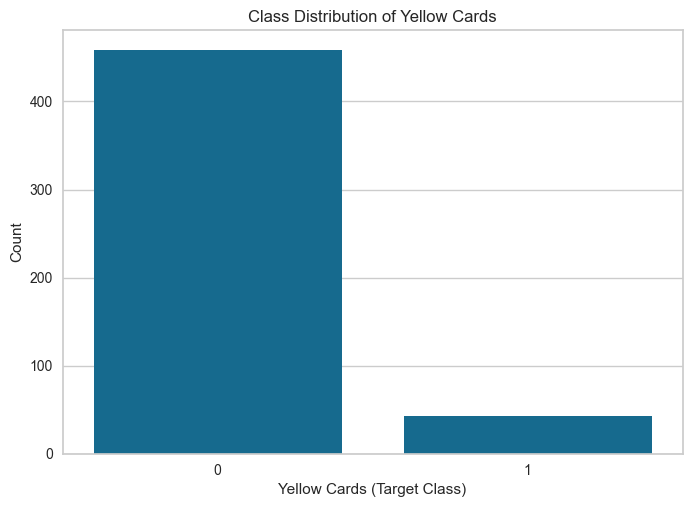

In [81]:
g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[y_features]
g_y_data_tar = g_y_data_tar[y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [82]:
g_y_base_model = setup(data=g_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 305, number of negative: 305
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001387 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7191
[LightGBM] [Info] Number of data points in the train set: 610, number of used features: 57
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(501, 75)"
4,Transformed data shape,"(761, 15)"
5,Transformed train set shape,"(610, 15)"
6,Transformed test set shape,"(151, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [83]:
best_base_g_y = g_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.6543,0.5646,0.4333,0.1090,0.1729,0.0435,0.0632,0.5240
svm,SVM - Linear Kernel,0.6143,0.5573,0.4667,0.1028,0.1678,0.0339,0.0533,0.9290
qda,Quadratic Discriminant Analysis,0.8371,0.5500,0.0333,0.0143,0.0200,-0.0607,-0.0629,0.6540
ada,Ada Boost Classifier,0.8286,0.5219,0.0667,0.0583,0.0619,-0.0302,-0.0312,0.5780
dt,Decision Tree Classifier,0.8029,0.5146,0.1667,0.1018,0.1223,0.0212,0.0230,0.9760
dummy,Dummy Classifier,0.9143,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.6350
gbc,Gradient Boosting Classifier,0.8857,0.4906,0.0333,0.0500,0.0400,-0.0011,-0.0033,0.8730
lightgbm,Light Gradient Boosting Machine,0.8857,0.4771,0.0000,0.0000,0.0000,-0.0375,-0.0402,2.7030
et,Extra Trees Classifier,0.9000,0.4760,0.0333,0.1000,0.0500,0.0250,0.0309,1.1870
lr,Logistic Regression,0.5943,0.4667,0.2667,0.0581,0.0952,-0.0487,-0.0667,0.7530


In [84]:
evaluate_model(best_base_g_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [85]:
tune_model_gk_y = tune_model(best_base_g_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6286,0.5104,0.3333,0.0833,0.1333,-0.0044,-0.0061
1,0.6857,0.7708,0.6667,0.1667,0.2667,0.1501,0.2089
2,0.6286,0.5208,0.3333,0.0833,0.1333,-0.0044,-0.0061
3,0.5714,0.5521,0.3333,0.0714,0.1176,-0.0274,-0.0417
4,0.6857,0.6771,0.6667,0.1667,0.2667,0.1501,0.2089
5,0.6286,0.5000,0.6667,0.1429,0.2353,0.1096,0.1667
6,0.6000,0.6875,0.6667,0.1333,0.2222,0.0926,0.1473
7,0.7714,0.6875,0.3333,0.1429,0.2000,0.0909,0.1021
8,0.6857,0.4896,0.3333,0.1000,0.1538,0.0253,0.0323


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [86]:
final_best_base_g_y = finalize_model(best_base_g_y)
save_model(final_best_base_g_y, './models/gk_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          min_child_we

## DEF


yellow_cards
0    1686
1     302
Name: count, dtype: int64


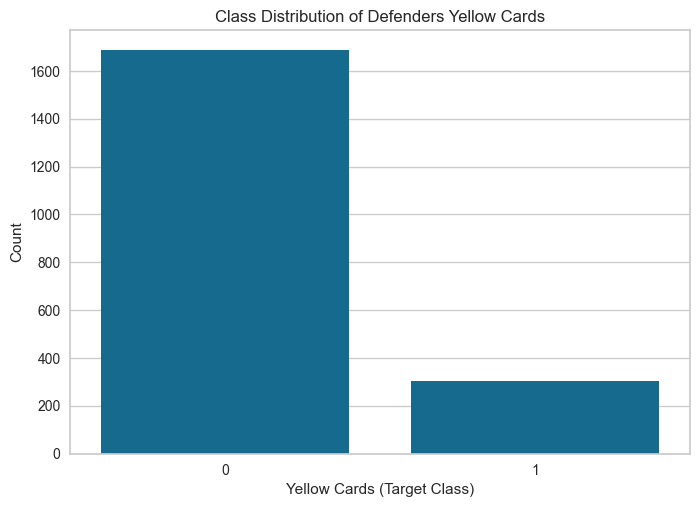

In [87]:
def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[y_features]
def_y_data_tar = def_y_data_tar[y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Defenders Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [88]:
def_y_base_model = setup(data=def_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1122, number of negative: 1122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012480 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14508
[LightGBM] [Info] Number of data points in the train set: 2244, number of used features: 68
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1988, 75)"
4,Transformed data shape,"(2841, 15)"
5,Transformed train set shape,"(2244, 15)"
6,Transformed test set shape,"(597, 15)"
7,Numeric features,73
8,Rows with missing values,0.1%
9,Preprocess,True


In [89]:
best_base_def_y = def_y_base_model.compare_models(sort='AUC')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,21:32:00
Status,. . . . . . . . . . . . . . . . . .,Selecting Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.8073,0.5461,0.0665,0.1692,0.0916,0.0082,0.0100,1.6610
qda,Quadratic Discriminant Analysis,0.5219,0.5368,0.5307,0.1652,0.2518,0.0268,0.0368,1.1120
lightgbm,Light Gradient Boosting Machine,0.8081,0.5326,0.0333,0.1136,0.0496,-0.0263,-0.0290,3.1860
et,Extra Trees Classifier,0.8030,0.5315,0.0617,0.1764,0.0889,0.0000,0.0054,0.9830
ada,Ada Boost Classifier,0.7376,0.5259,0.1615,0.1588,0.1574,0.0045,0.0046,1.1470
nb,Naive Bayes,0.4622,0.5238,0.5922,0.1584,0.2497,0.0141,0.0233,0.7860
ridge,Ridge Classifier,0.5414,0.5230,0.5448,0.1751,0.2649,0.0459,0.0615,0.7970
lr,Logistic Regression,0.5414,0.5229,0.5400,0.1739,0.2629,0.0436,0.0587,0.8560
lda,Linear Discriminant Analysis,0.5407,0.5229,0.5448,0.1748,0.2645,0.0454,0.0609,0.7400
xgboost,Extreme Gradient Boosting,0.7901,0.5209,0.0381,0.0778,0.0509,-0.0477,-0.0536,2.5710


In [90]:
evaluate_model(best_base_def_cs)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

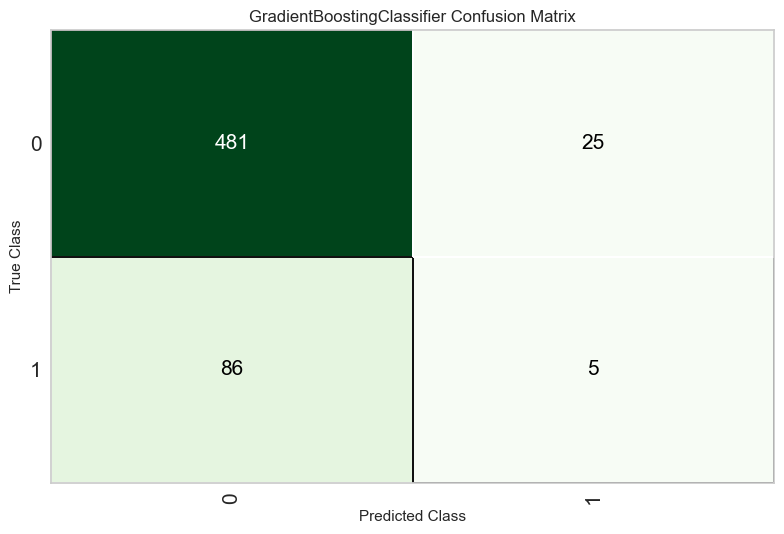

In [91]:
plot_model(best_base_def_y, plot='confusion_matrix')

### Tuned Model


In [92]:
tune_model_def_y = tune_model(best_base_def_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7857,0.5990,0.0909,0.1667,0.1176,0.0076,0.0080
1,0.7842,0.5367,0.1905,0.2353,0.2105,0.0871,0.0878
2,0.7914,0.5638,0.2381,0.2778,0.2564,0.1359,0.1365
3,0.6978,0.4887,0.1429,0.1111,0.1250,-0.0542,-0.0548
4,0.8273,0.6425,0.0952,0.2857,0.1429,0.0728,0.0866
5,0.7986,0.6251,0.1905,0.2667,0.2222,0.1102,0.1123
6,0.7698,0.4665,0.1429,0.1765,0.1579,0.0263,0.0265
7,0.7482,0.5876,0.1429,0.1500,0.1463,-0.0012,-0.0012
8,0.7050,0.4657,0.0952,0.0833,0.0889,-0.0861,-0.0864


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [93]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [94]:
final_best_base_def_y = finalize_model(best_base_def_y)
save_model(final_best_base_def_y, './models/def_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                             criterion='friedman_mse', init=None,
                    

## MID


yellow_cards
0    1855
1     340
Name: count, dtype: int64


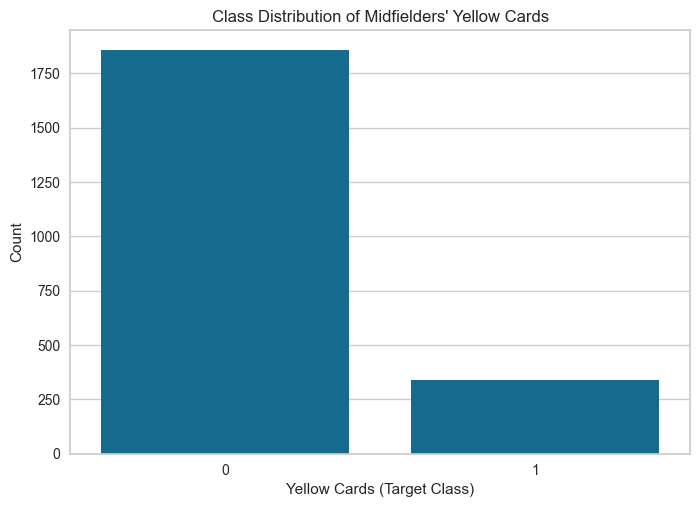

In [95]:
mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[y_features]
mid_y_data_tar = mid_y_data_tar[y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Midfielders\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [96]:
mid_y_base_model = setup(data=mid_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 1227, number of negative: 1227
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002197 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15037
[LightGBM] [Info] Number of data points in the train set: 2454, number of used features: 67
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(2195, 75)"
4,Transformed data shape,"(3113, 15)"
5,Transformed train set shape,"(2454, 15)"
6,Transformed test set shape,"(659, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [97]:
best_base_mid_y = mid_y_base_model.compare_models(sort='AUC')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,21:40:33
Status,. . . . . . . . . . . . . . . . . .,Loading Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.7403,0.5706,0.2188,0.1966,0.2041,0.0521,0.0524,1.2890
lightgbm,Light Gradient Boosting Machine,0.8119,0.5652,0.0882,0.2531,0.1258,0.0447,0.0566,1.8680
qda,Quadratic Discriminant Analysis,0.5937,0.5568,0.4127,0.1676,0.2373,0.0233,0.0292,1.0430
gbc,Gradient Boosting Classifier,0.8073,0.5560,0.0929,0.1818,0.1194,0.0351,0.0337,1.4580
nb,Naive Bayes,0.5507,0.5526,0.4697,0.1632,0.2416,0.0174,0.0254,1.0210
lr,Logistic Regression,0.5612,0.5473,0.4458,0.1615,0.2367,0.0138,0.0200,1.2420
lda,Linear Discriminant Analysis,0.5592,0.5468,0.4417,0.1598,0.2342,0.0104,0.0158,1.1590
ridge,Ridge Classifier,0.5592,0.5467,0.4417,0.1598,0.2342,0.0104,0.0158,0.9280
xgboost,Extreme Gradient Boosting,0.7995,0.5459,0.0712,0.1521,0.0961,0.0040,0.0025,1.8130
et,Extra Trees Classifier,0.8092,0.5412,0.1009,0.2361,0.1390,0.0520,0.0585,1.5380


In [98]:
evaluate_model(best_base_mid_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [99]:
tune_model_mid_y = tune_model(best_base_mid_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6558,0.5135,0.4167,0.2041,0.2740,0.0819,0.0909
1,0.5325,0.5282,0.2917,0.1129,0.1628,-0.0799,-0.0972
2,0.6883,0.5793,0.3333,0.2000,0.2500,0.0685,0.0721
3,0.6104,0.4728,0.3333,0.1538,0.2105,-0.0035,-0.0039
4,0.6688,0.4394,0.0000,0.0000,0.0000,-0.1976,-0.1981
5,0.7403,0.5766,0.1667,0.1667,0.1667,0.0128,0.0128
6,0.6536,0.5368,0.3913,0.1875,0.2535,0.0631,0.0703
7,0.7712,0.5090,0.1739,0.2000,0.1860,0.0537,0.0539
8,0.6993,0.6252,0.2500,0.1765,0.2069,0.0282,0.0288


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [100]:
evaluate_model(tune_model_def_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [101]:
final_best_base_mid_y = finalize_model(tune_model_mid_y)
save_model(final_best_base_mid_y, './models/mid_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          num_leaves=3

## FWD


yellow_cards
0    448
1     49
Name: count, dtype: int64


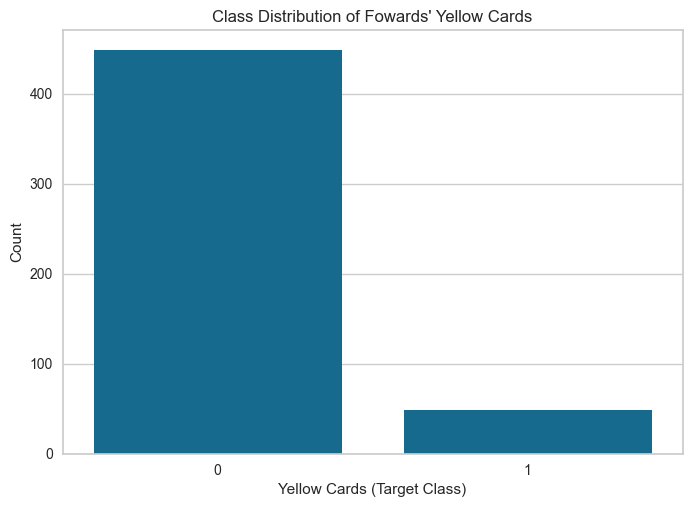

In [102]:
fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[y_features]
fwd_y_data_tar = fwd_y_data_tar[y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Fowards\' Yellow Cards')
plt.xlabel('Yellow Cards (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [103]:
fwd_y_base_model = setup(data=fwd_y_data, target='yellow_cards',
                        fix_imbalance=True,
                        remove_outliers=True,
                        normalize=True,
                        feature_selection=True,
                        session_id=123)

[LightGBM] [Info] Number of positive: 296, number of negative: 296
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000707 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8963
[LightGBM] [Info] Number of data points in the train set: 592, number of used features: 63
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(497, 75)"
4,Transformed data shape,"(742, 15)"
5,Transformed train set shape,"(592, 15)"
6,Transformed test set shape,"(150, 15)"
7,Numeric features,73
8,Preprocess,True
9,Imputation type,simple


In [104]:
best_base_fwd_y = fwd_y_base_model.compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.6000,0.5128,0.4250,0.1040,0.1664,0.0140,0.0255,0.4690
et,Extra Trees Classifier,0.8761,0.5120,0.0000,0.0000,0.0000,-0.0387,-0.0440,0.5830
rf,Random Forest Classifier,0.8503,0.5117,0.0000,0.0000,0.0000,-0.0684,-0.0718,0.9240
qda,Quadratic Discriminant Analysis,0.8248,0.5098,0.0917,0.1000,0.0936,0.0156,0.0110,0.5950
ridge,Ridge Classifier,0.6000,0.5096,0.4250,0.1040,0.1664,0.0140,0.0255,0.7640
dt,Decision Tree Classifier,0.7549,0.5074,0.2000,0.1153,0.1390,0.0155,0.0166,0.4420
lr,Logistic Regression,0.6230,0.5072,0.4250,0.1100,0.1742,0.0256,0.0408,0.5150
nb,Naive Bayes,0.5971,0.5061,0.4500,0.1093,0.1742,0.0218,0.0353,0.4180
dummy,Dummy Classifier,0.9021,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.5400
knn,K Neighbors Classifier,0.5881,0.4935,0.4000,0.1042,0.1629,0.0105,0.0093,0.5040


In [105]:
evaluate_model(best_base_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Tuned Model


In [106]:
tune_model_fwd_y = tune_model(best_base_fwd_y,  optimize='AUC')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5714,0.4792,0.3333,0.0714,0.1176,-0.0274,-0.0417
1,0.5714,0.2917,0.0000,0.0000,0.0000,-0.1589,-0.2212
2,0.6000,0.6562,0.6667,0.1333,0.2222,0.0926,0.1473
3,0.5143,0.5968,0.7500,0.1579,0.2609,0.0888,0.1494
4,0.6286,0.6452,0.5000,0.1538,0.2353,0.0733,0.0956
5,0.5429,0.4919,0.5000,0.1250,0.2000,0.0210,0.0309
6,0.5714,0.4919,0.2500,0.0769,0.1176,-0.0692,-0.0903
7,0.6765,0.5054,0.3333,0.1000,0.1538,0.0209,0.0268
8,0.6471,0.4194,0.0000,0.0000,0.0000,-0.1525,-0.1867


Fitting 10 folds for each of 10 candidates, totalling 100 fits


In [107]:
evaluate_model(tune_model_fwd_y)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [108]:
final_best_base_fwd_y = finalize_model(tune_model_fwd_y)
save_model(final_best_base_fwd_y, './models/fwd_y_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                          reg_alpha=0.